# Criando um AgentExecutor com memória 

Para criarmos uma aplicação funcional de chat com nosso aggent, é necessário que ele tenha a capacidade de armazenar as informações trocadas com o usuário. E para isso, adicionamos o componente de memory já visto anteriormente no curso de Aplicações de IA com LangChain.

## Criando as tools que usaremos

In [8]:
import requests
import datetime

from langchain.agents import tool
from pydantic import BaseModel, Field #Importação atualizada

import wikipedia
wikipedia.set_lang('pt')

class RetornTempArgs(BaseModel):
    latitude: float = Field(description='Latitude da localidade que buscamos a temperatura')
    longitude: float = Field(description='Longitude da localidade que buscamos a temperatura')


@tool(args_schema=RetornTempArgs)
def retorna_temperatura_atual(latitude: float, longitude: float):
    '''Retorna a temperatura atual para uma dada coordenada'''

    URL = 'https://api.open-meteo.com/v1/forecast'

    params = {
        'latitude': latitude,
        'longitude': longitude,
        'hourly': 'temperature_2m',
        'forecast_days': 1,
    }

    resposta = requests.get(URL, params=params)
    if resposta.status_code == 200:
        resultado = resposta.json()
        
        hora_agora = datetime.datetime.now(datetime.UTC).replace(tzinfo=None)
        lista_horas = [datetime.datetime.fromisoformat(temp_str) for temp_str in resultado['hourly']['time']]
        index_mais_prox = min(range(len(lista_horas)), key=lambda x: abs(lista_horas[x] - hora_agora))

        temp_atual = resultado['hourly']['temperature_2m'][index_mais_prox]
        return f'{temp_atual}ºC'
    else:
        raise Exception(f'Request para API {URL} falhou: {resposta.status_code}')

@tool
def busca_wikipedia(query: str):
    """Faz busca no wikipedia e retorna resumos de páginas para a query"""
    titulos_paginas = wikipedia.search(query)
    resumos = []
    for titulo in titulos_paginas[:3]:
        try:
            wiki_page = wikipedia.page(title=titulo, auto_suggest=True)
            resumos.append(f'Título da página: {titulo}\nResumo: {wiki_page.summary}')
        except:
            pass
    if not resumos:
        return 'Busca não teve retorno'
    else:
        return '\n\n'.join(resumos)

## O que temos no final?

In [2]:
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai.chat_models import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.agent import AgentFinish
from langchain.agents.output_parsers import OpenAIFunctionsAgentOutputParser
from langchain_core.utils.function_calling import convert_to_openai_function
from langchain.agents.format_scratchpad import format_to_openai_function_messages


chat = ChatOpenAI()

tools = [busca_wikipedia, retorna_temperatura_atual]
tools_json = [convert_to_openai_function(tool) for tool in tools]
tool_run = {tool.name: tool for tool in tools}

### Um Agent

In [3]:
prompt = ChatPromptTemplate.from_messages([
    ('system', 'Você é um assistente amigável chamado Isaac'),
    ('user', '{input}'),
    MessagesPlaceholder(variable_name='agent_scratchpad')
])

pass_through = RunnablePassthrough.assign(
    agent_scratchpad = lambda x: format_to_openai_function_messages(x['intermediate_steps'])
)
agent_chain = pass_through | prompt | chat.bind(functions=tools_json) | OpenAIFunctionsAgentOutputParser()

### Um AgentExecutor

In [4]:
def run_agent(input):
    passos_intermediarios = []
    while True:
        resposta = agent_chain.invoke({
            'input': input,
            'intermediate_steps': passos_intermediarios
        })
        if isinstance(resposta, AgentFinish):
            return resposta
        observacao = tool_run[resposta.tool].run(resposta.tool_input)
        passos_intermediarios.append((resposta, observacao))

In [5]:
resposta = run_agent({'input': 'Qual é a temperatura em Porto Alegre?'})
resposta

AgentFinish(return_values={'output': 'A temperatura atual em Porto Alegre é de 33.6ºC.'}, log='A temperatura atual em Porto Alegre é de 33.6ºC.')

In [6]:
resposta = run_agent({'input': 'Olá, eu sou o Adriano'})
resposta

AgentFinish(return_values={'output': 'Olá, Adriano! Como posso te ajudar hoje? 🌟'}, log='Olá, Adriano! Como posso te ajudar hoje? 🌟')

In [7]:
resposta = run_agent({'input': 'Qual o meu nome?'})
resposta

AgentFinish(return_values={'output': 'Seu nome é "{{user_name}}", certo? Como posso te ajudar hoje?'}, log='Seu nome é "{{user_name}}", certo? Como posso te ajudar hoje?')

## LangChain AgentExecutor

O LangChain fornece uma estrutura pronta de AgentExecutors. Além de já fazer o loop necessário para processamento das mensagens trocadas com o modelo, ele permite algumas outras funcionalidades como verbose=True que facilita o debugar e a adição de memórias que veremos a seguir:

In [8]:
from langchain.agents import AgentExecutor

agent_executor = AgentExecutor(
    agent=agent_chain,
    tools=tools,
    verbose=True
)

In [9]:
resposta = agent_executor.invoke({'input': 'Qual é a temperatura em Porto Alegre?'})
resposta



> Entering new AgentExecutor chain...

Invoking: `retorna_temperatura_atual` with `{'latitude': -30.0346, 'longitude': -51.2177}`


33.6ºCA temperatura em Porto Alegre atualmente é de 33.6ºC.

> Finished chain.


{'input': 'Qual é a temperatura em Porto Alegre?',
 'output': 'A temperatura em Porto Alegre atualmente é de 33.6ºC.'}

In [10]:
resposta = agent_executor.invoke({'input': 'Olá'})
resposta



> Entering new AgentExecutor chain...
Olá! Como posso ajudar você hoje?

> Finished chain.


{'input': 'Olá', 'output': 'Olá! Como posso ajudar você hoje?'}

In [11]:
resposta = agent_executor.invoke({'input': 'Meu nome é Adriano'})
resposta



> Entering new AgentExecutor chain...
Olá, Adriano! Como posso te ajudar hoje?

> Finished chain.


{'input': 'Meu nome é Adriano',
 'output': 'Olá, Adriano! Como posso te ajudar hoje?'}

In [12]:
resposta = agent_executor.invoke({'input': 'Qual o meu nome?'})
resposta



> Entering new AgentExecutor chain...
Desculpe, não consigo saber o seu nome. Como posso ajudá-lo hoje?

> Finished chain.


{'input': 'Qual o meu nome?',
 'output': 'Desculpe, não consigo saber o seu nome. Como posso ajudá-lo hoje?'}

## Adicionando memória

Vamos usar uma memória bem simples neste caso e mostrar as modificações necessárias no prompt e no AgentExecutor:

In [13]:
from langchain.memory import ConversationBufferMemory
memory = ConversationBufferMemory(
    return_messages=True,
    memory_key='chat_history'
)


/tmp/ipykernel_145908/482711709.py:2: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


In [14]:
prompt = ChatPromptTemplate.from_messages([
    ('system', 'Você é um assistente amigável chamado Isaac'),
    MessagesPlaceholder(variable_name='chat_history'),
    ('user', '{input}'),
    MessagesPlaceholder(variable_name='agent_scratchpad')
])

pass_through = RunnablePassthrough.assign(
    agent_scratchpad = lambda x: format_to_openai_function_messages(x['intermediate_steps'])
)
agent_chain = pass_through | prompt | chat.bind(functions=tools_json) | OpenAIFunctionsAgentOutputParser()

In [15]:
from langchain.agents import AgentExecutor

agent_executor = AgentExecutor(
    agent=agent_chain,
    tools=tools,
    memory=memory,
    verbose=True
)

In [16]:
resposta = agent_executor.invoke({'input': 'Meu nome é Adriano'})
resposta



> Entering new AgentExecutor chain...
Olá, Adriano! Como posso te ajudar hoje?

> Finished chain.


{'input': 'Meu nome é Adriano',
 'chat_history': [HumanMessage(content='Meu nome é Adriano', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Olá, Adriano! Como posso te ajudar hoje?', additional_kwargs={}, response_metadata={})],
 'output': 'Olá, Adriano! Como posso te ajudar hoje?'}

In [17]:
resposta = agent_executor.invoke({'input': 'Qual o meu nome?'})
resposta



> Entering new AgentExecutor chain...
Seu nome é Adriano. Como posso te ajudar hoje, Adriano?

> Finished chain.


{'input': 'Qual o meu nome?',
 'chat_history': [HumanMessage(content='Meu nome é Adriano', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Olá, Adriano! Como posso te ajudar hoje?', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Qual o meu nome?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Seu nome é Adriano. Como posso te ajudar hoje, Adriano?', additional_kwargs={}, response_metadata={})],
 'output': 'Seu nome é Adriano. Como posso te ajudar hoje, Adriano?'}

In [11]:
# === IMPORTAÇÕES NECESSÁRIAS ===
import requests
import datetime
import wikipedia
from langchain.agents import tool, AgentExecutor
from pydantic import BaseModel, Field
from langchain_core.utils.function_calling import convert_to_openai_function
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents.output_parsers import OpenAIFunctionsAgentOutputParser
from langchain_core.agents import AgentFinish
from langchain.memory import ConversationBufferMemory
from langchain.schema.runnable import RunnablePassthrough
from langchain.agents.format_scratchpad import format_to_openai_function_messages

# === Memória de Conversação ===
memory = ConversationBufferMemory(
    return_messages=True,
    memory_key='chat_history'
)

# === TOOL: Temperatura ===
class RetornTempArgs(BaseModel):
    latitude: float = Field(description='Latitude da localidade que buscamos a temperatura')
    longitude: float = Field(description='Longitude da localidade que buscamos a temperatura')

@tool(args_schema=RetornTempArgs)
def retorna_temperatura_atual(latitude: float, longitude: float):
    '''Retorna a temperatura atual para uma dada coordenada'''
    URL = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude': latitude,
        'longitude': longitude,
        'hourly': 'temperature_2m',
        'forecast_days': 1,
    }

    resposta = requests.get(URL, params=params)
    if resposta.status_code == 200:
        resultado = resposta.json()
        hora_agora = datetime.datetime.now(datetime.UTC).replace(tzinfo=None)
        lista_horas = [datetime.datetime.fromisoformat(temp_str) for temp_str in resultado['hourly']['time']]
        index_mais_prox = min(range(len(lista_horas)), key=lambda x: abs(lista_horas[x] - hora_agora))
        temp_atual = resultado['hourly']['temperature_2m'][index_mais_prox]
        return f"A temperatura atual é {temp_atual}°C"
    else:
        raise Exception(f'Request para API {URL} falhou: {resposta.status_code}')

# === TOOL: Wikipedia ===
wikipedia.set_lang('pt')

@tool
def busca_wikipedia(query: str):
    """Faz busca no wikipedia e retorna resumos de páginas para a query"""
    titulos_paginas = wikipedia.search(query)
    resumos = []
    for titulo in titulos_paginas[:3]:
        try:
            wiki_page = wikipedia.page(title=titulo, auto_suggest=True)
            resumos.append(f'Título da página: {titulo}\nResumo: {wiki_page.summary}')
        except:
            pass
    if not resumos:
        return 'Busca não teve retorno'
    else:
        return '\n\n'.join(resumos)

# === DEFININDO TOOLS ===
tools = [busca_wikipedia, retorna_temperatura_atual]
tools_json = [convert_to_openai_function(tool) for tool in tools]
tool_run = {tool.name: tool for tool in tools}

# === MODELO ===
model = ChatGoogleGenerativeAI(model="gemini-2.0-flash-lite")

# === PROMPT ===
prompt = ChatPromptTemplate.from_messages([
    ('system', 'Você é um assistente amigável chamado Isaac'),
    MessagesPlaceholder(variable_name='chat_history'),
    ('user', '{input}'),
    MessagesPlaceholder(variable_name='agent_scratchpad')
])

pass_through = RunnablePassthrough.assign(
    agent_scratchpad=lambda x: format_to_openai_function_messages(x['intermediate_steps']),
    chat_history=lambda x: memory.chat_memory.messages
)

# === AGENTE COMBINADO COM TOOLS ===
agent_chain = (
    pass_through 
    | prompt
    | model.bind(functions=tools_json)
    | OpenAIFunctionsAgentOutputParser()
)

# === AGENT EXECUTOR ===
agent_executor = AgentExecutor(
    agent=agent_chain,
    tools=tools,
    memory=memory,
    verbose=True
)

# === TESTE ===
resposta = agent_executor.invoke({'input': 'Qual é a temperatura em Porto Alegre?'})
print(resposta)

resposta1 = agent_executor.invoke({'input': 'Meu nome é Adriano'})
print(resposta1)

respost2 = agent_executor.invoke({'input': 'Qual o meu nome?'})
respost2




> Entering new AgentExecutor chain...
Eu preciso da latitude e longitude de Porto Alegre para buscar a temperatura. Você pode me fornecer?

> Finished chain.
{'input': 'Qual é a temperatura em Porto Alegre?', 'chat_history': [HumanMessage(content='Qual é a temperatura em Porto Alegre?', additional_kwargs={}, response_metadata={}), AIMessage(content='Eu preciso da latitude e longitude de Porto Alegre para buscar a temperatura. Você pode me fornecer?', additional_kwargs={}, response_metadata={})], 'output': 'Eu preciso da latitude e longitude de Porto Alegre para buscar a temperatura. Você pode me fornecer?'}


> Entering new AgentExecutor chain...
Olá Adriano, como posso te ajudar hoje?

> Finished chain.
{'input': 'Meu nome é Adriano', 'chat_history': [HumanMessage(content='Qual é a temperatura em Porto Alegre?', additional_kwargs={}, response_metadata={}), AIMessage(content='Eu preciso da latitude e longitude de Porto Alegre para buscar a temperatura. Você pode me fornecer?', additi

{'input': 'Qual o meu nome?',
 'chat_history': [HumanMessage(content='Qual é a temperatura em Porto Alegre?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Eu preciso da latitude e longitude de Porto Alegre para buscar a temperatura. Você pode me fornecer?', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Meu nome é Adriano', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Olá Adriano, como posso te ajudar hoje?', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Qual o meu nome?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Seu nome é Adriano.', additional_kwargs={}, response_metadata={})],
 'output': 'Seu nome é Adriano.'}

In [7]:
import numpy as np

# Parâmetros
aporte_mensal = 499
meses = 60

# Alocação por categoria
alocacao = {
    "Tesouro Selic / CDB": 0.50,
    "LCI / LCA": 0.30,
    "Fundo Cripto (Hashdex)": 0.20
}

# Rentabilidades anuais estimadas (real líquida)
rentabilidades = {
    "Tesouro Selic / CDB": 0.06,
    "LCI / LCA": 0.07,
    "Fundo Cripto (Hashdex)": 0.15
}

def simular_dca(aporte_mensal, meses, rent_anual):
    rent_mensal = (1 + rent_anual) ** (1 / 12) - 1
    saldo = 0
    for _ in range(meses):
        saldo = saldo * (1 + rent_mensal) + aporte_mensal
    return saldo

# Simulação
total_final = 0
print("Resultado após 5 anos:\n")
for nome, percentual in alocacao.items():
    aporte_mensal_categoria = aporte_mensal * percentual
    saldo = simular_dca(aporte_mensal_categoria, meses, rentabilidades[nome])
    total_final += saldo
    print(f"{nome}: R$ {saldo:,.2f}")

total_aportado = aporte_mensal * meses
lucro = total_final - total_aportado

print(f"\nTotal Aportado: R$ {total_aportado:,.2f}")
print(f"Valor Final Estimado: R$ {total_final:,.2f}")
print(f"Lucro Estimado: R$ {lucro:,.2f}")

Resultado após 5 anos:

Tesouro Selic / CDB: R$ 17,336.70
LCI / LCA: R$ 10,658.02
Fundo Cripto (Hashdex): R$ 8,615.81

Total Aportado: R$ 29,940.00
Valor Final Estimado: R$ 36,610.53
Lucro Estimado: R$ 6,670.53


Coletando dados para BTC...
Coletando dados para ETH...
Coletando dados para BNB...
Coletando dados para XRP...
Coletando dados para USDC...
Coletando dados para USDT...
Coletando dados para SOL...
Erro na requisição para solana: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/solana/market_chart?vs_currency=brl&days=365&interval=daily
Coletando dados para DOT...
Erro na requisição para polkadot: 429 Client Error: Too Many Requests for url: https://api.coingecko.com/api/v3/coins/polkadot/market_chart?vs_currency=brl&days=365&interval=daily

Estatísticas de Retornos Diários:
          mean       std
BTC   0.001835  0.026037
ETH   0.001174  0.039116
BNB   0.001332  0.027057
XRP   0.005889  0.052362
USDC  0.000018  0.010821
USDT  0.000018  0.010745

Sharpe Ratios (quanto maior, melhor):
XRP     0.112474
BTC     0.070485
BNB     0.049243
ETH     0.030005
USDT    0.001709
USDC    0.001653
dtype: float64


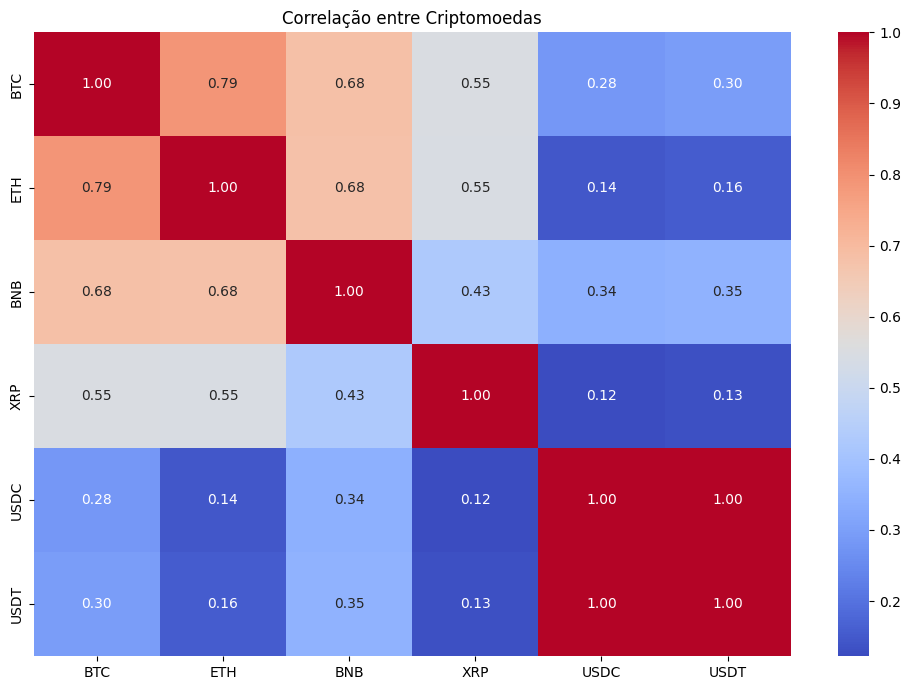

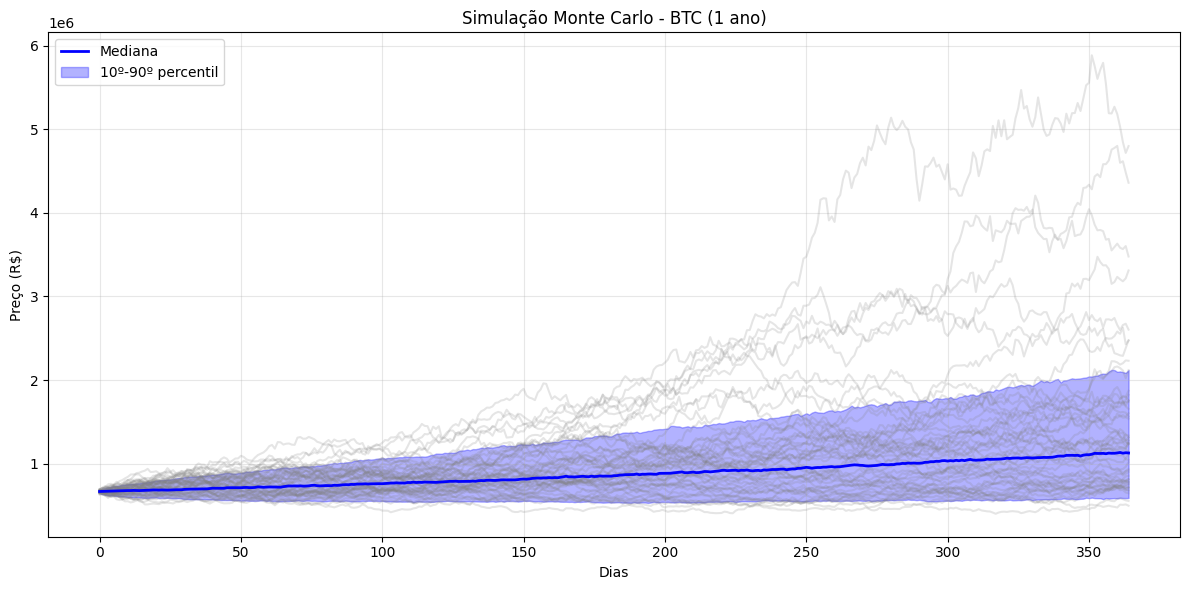

In [6]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import time

# Função para buscar preços históricos do CoinGecko
def get_price_history(coin_id, days='365'):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        'vs_currency': 'brl',
        'days': days,
        'interval': 'daily'
    }
    
    try:
        r = requests.get(url, params=params)
        r.raise_for_status()  # Raises exception for bad status codes
        data = r.json()
        
        if 'prices' not in data:
            print(f"Erro: dados não encontrados para {coin_id}")
            return None
            
        prices = data['prices']
        df = pd.DataFrame(prices, columns=['timestamp', coin_id])
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        df.set_index('timestamp', inplace=True)
        return df
        
    except requests.exceptions.RequestException as e:
        print(f"Erro na requisição para {coin_id}: {e}")
        return None
    except Exception as e:
        print(f"Erro ao processar dados para {coin_id}: {e}")
        return None

# Moedas e IDs do CoinGecko
moedas = {
    'bitcoin': 'BTC',
    'ethereum': 'ETH',
    'binancecoin': 'BNB',
    'ripple': 'XRP',
    'usd-coin': 'USDC',
    'tether': 'USDT',
    'solana': 'SOL',
    'polkadot': 'DOT'
}

# Coletar os dados com rate limiting
dfs = []
for coin, symbol in moedas.items():
    print(f"Coletando dados para {symbol}...")
    df = get_price_history(coin)
    if df is not None:
        df.rename(columns={coin: symbol}, inplace=True)
        dfs.append(df)
    time.sleep(1)  # Rate limiting - 1 segundo entre requests

if not dfs:
    raise Exception("Nenhum dado foi coletado com sucesso")

# Unificar os dados
df_all = pd.concat(dfs, axis=1, join='inner')  # inner join para garantir alinhamento
df_all.dropna(inplace=True)

if df_all.empty:
    raise Exception("DataFrame final está vazio após limpeza")

# Calcular retornos diários
returns = df_all.pct_change().dropna()

# Estatísticas básicas
print("\nEstatísticas de Retornos Diários:")
print(returns.describe().T[['mean', 'std']])

# Sharpe Ratio (assumindo taxa livre de risco ~0)
sharpe_ratios = returns.mean() / returns.std()
print("\nSharpe Ratios (quanto maior, melhor):")
print(sharpe_ratios.sort_values(ascending=False))

# Correlação entre criptos
plt.figure(figsize=(10, 7))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlação entre Criptomoedas")
plt.tight_layout()
plt.show()

# Simulação de Monte Carlo (exemplo para Bitcoin)
def monte_carlo_simulation(prices, num_simulations=1000, num_days=365):
    if len(prices) < 2:
        raise ValueError("Precisa de pelo menos 2 pontos de preço")
        
    last_price = prices[-1]
    returns = np.diff(prices) / prices[:-1]
    mean_return = np.mean(returns)
    std_dev = np.std(returns)

    simulations = np.zeros((num_simulations, num_days))

    for i in range(num_simulations):
        price_series = [last_price]
        for _ in range(num_days):
            random_return = np.random.normal(mean_return, std_dev)
            price = price_series[-1] * (1 + random_return)
            price = max(price, 0)  # Evita preços negativos
            price_series.append(price)
        simulations[i] = price_series[1:]

    return simulations

# Rodar simulação para BTC
if 'BTC' in df_all.columns:
    btc_prices = df_all['BTC'].values
    simulations = monte_carlo_simulation(btc_prices)

    # Visualizar simulações
    plt.figure(figsize=(12, 6))
    for sim in simulations[:50]:
        plt.plot(sim, color='gray', alpha=0.2)
    
    # Adicionar percentis
    percentiles = np.percentile(simulations, [10, 50, 90], axis=0)
    plt.plot(percentiles[1], color='blue', linewidth=2, label='Mediana')
    plt.fill_between(range(len(percentiles[0])), percentiles[0], percentiles[2], 
                     alpha=0.3, color='blue', label='10º-90º percentil')
    
    plt.title("Simulação Monte Carlo - BTC (1 ano)")
    plt.xlabel("Dias")
    plt.ylabel("Preço (R$)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Dados do Bitcoin não disponíveis para simulação")
